<a href="https://colab.research.google.com/github/kalyaninivant/Digital_Image_Processing-/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Bit plane slicing.bmp to Bit plane slicing.bmp


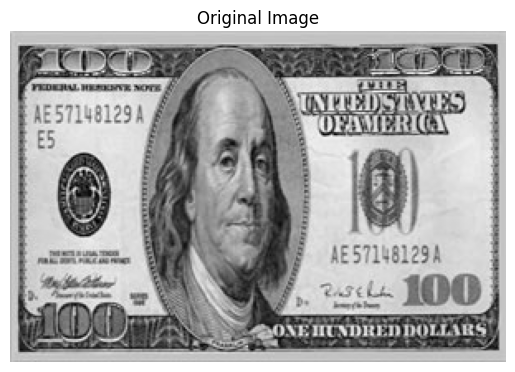

Original Bits: 480000
Compressed Bits: 455043
Compression Ratio: 1.0548453662620896


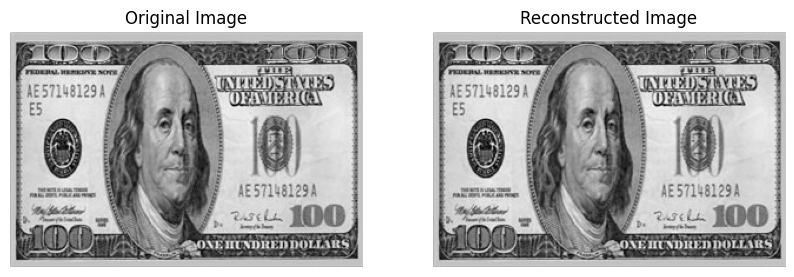

In [1]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
import heapq
from collections import defaultdict


# =========================================================
# 2. UPLOAD & LOAD IMAGE (GRAYSCALE)
# =========================================================
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()


# =========================================================
# 3. HUFFMAN TREE NODE
# =========================================================
class Node:
    def __init__(self, value, freq):
        self.value = value
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq


# =========================================================
# 4. BUILD HUFFMAN TREE
# =========================================================
def build_huffman_tree(freq_dict):
    heap = []

    for value in freq_dict:
        heapq.heappush(heap, Node(value, freq_dict[value]))

    while len(heap) > 1:
        left = heapq.heappop(heap)
        right = heapq.heappop(heap)

        merged = Node(None, left.freq + right.freq)
        merged.left = left
        merged.right = right

        heapq.heappush(heap, merged)

    return heap[0]


# =========================================================
# 5. GENERATE HUFFMAN CODES
# =========================================================
def generate_codes(node, current_code="", codes={}):
    if node is None:
        return

    if node.value is not None:
        codes[node.value] = current_code
        return

    generate_codes(node.left, current_code + "0", codes)
    generate_codes(node.right, current_code + "1", codes)

    return codes


# =========================================================
# 6. ENCODE IMAGE
# =========================================================
def encode_image(image, codes):
    flat = image.flatten()
    encoded = "".join([codes[pixel] for pixel in flat])
    return encoded


# =========================================================
# 7. DECODE IMAGE
# =========================================================
def decode_image(encoded, root, shape):
    decoded_pixels = []
    node = root

    for bit in encoded:
        if bit == '0':
            node = node.left
        else:
            node = node.right

        if node.value is not None:
            decoded_pixels.append(node.value)
            node = root

    return np.array(decoded_pixels).reshape(shape)


# =========================================================
# 8. MAIN PROCESS
# =========================================================

# Frequency calculation
freq = defaultdict(int)
for pixel in img.flatten():
    freq[pixel] += 1

# Build tree
root = build_huffman_tree(freq)

# Generate codes
codes = generate_codes(root)

# Encode
encoded_data = encode_image(img, codes)

# Decode
decoded_img = decode_image(encoded_data, root, img.shape)


# =========================================================
# 9. COMPRESSION ANALYSIS
# =========================================================
original_bits = img.size * 8
compressed_bits = len(encoded_data)

compression_ratio = original_bits / compressed_bits

print("Original Bits:", original_bits)
print("Compressed Bits:", compressed_bits)
print("Compression Ratio:", compression_ratio)


# =========================================================
# 10. DISPLAY RESULTS
# =========================================================
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Reconstructed Image")
plt.imshow(decoded_img, cmap='gray')
plt.axis('off')

plt.show()